In [1]:
from transformers import BertTokenizer
import string
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [2]:
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 '_processor_class',
 '_save_pretrained',
 '_set_model_specific_s

In [3]:
all_tokens = list(tokenizer.get_vocab().keys())
all_tokens[20000:20100]

['##せ',
 'column',
 'almost',
 'correctly',
 'hardcover',
 'cones',
 '##ʀ',
 'bankers',
 'luckily',
 '##fall',
 'agatha',
 'typhoon',
 'depths',
 'rocker',
 'pornographic',
 'ruse',
 'modular',
 'amino',
 'citizen',
 'configured',
 'quit',
 '##cape',
 'aperture',
 'camera',
 'wheeling',
 'dubai',
 '##icing',
 'gorilla',
 '[unused312]',
 'claire',
 '##ς',
 'beatty',
 'modifying',
 'territorial',
 'walker',
 'batman',
 'summoned',
 'hugs',
 '##zek',
 'paddle',
 'disposed',
 'simon',
 '…',
 '##dina',
 '##ett',
 '##bbies',
 'renaissance',
 '##ს',
 '1735',
 '##gaon',
 '##ral',
 'vikram',
 'style',
 'portraits',
 '##inatory',
 'helicopter',
 '##sse',
 'dorset',
 'steak',
 'refreshing',
 'willis',
 'human',
 'phosphate',
 'volunteers',
 'operatives',
 'syria',
 'committee',
 'experiment',
 'weeping',
 'startled',
 'femme',
 'marriages',
 '##ched',
 'endeavors',
 'margaret',
 'barry',
 '1796',
 'georgina',
 'stops',
 '##scent',
 'brazil',
 '##ᅵ',
 'belongings',
 'wisconsin',
 'kraft',
 'dion',

In [4]:
print(tokenizer.vocab_size)
tokenizer.get_vocab()['science']

30522


2671

In [5]:
word = 'science'

res1 = tokenizer.convert_tokens_to_ids(word)
res2 = tokenizer.get_vocab()[word]
print(res1)
print(res2)

2671
2671


In [6]:
text = "Science is great"
res3 = tokenizer.encode(text)

for t in res3:
  print(f'Token {t} is "{tokenizer.decode(t)}"')

print('')
print(tokenizer.decode(res3,skip_special_tokens=True))
print(tokenizer.decode(res3,skip_special_tokens=False))

Token 101 is "[CLS]"
Token 2671 is "science"
Token 2003 is "is"
Token 2307 is "great"
Token 102 is "[SEP]"

science is great
[CLS] science is great [SEP]


In [7]:
# BERT adds [CLS]...[SEP] with each encode
tokenizer.decode(tokenizer.encode(tokenizer.decode(tokenizer.encode( text ))))

'[CLS] [CLS] science is great [SEP] [SEP]'

In [8]:
tokenizer(text)

{'input_ids': [101, 2671, 2003, 2307, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

In [9]:
sentence = 'AI is both exciting and terrifying.'

print('Original sentence:')
print(f'  {sentence}\n')

# segment the text into tokens
tokenized = tokenizer.tokenize(sentence)
print('Tokenized (segmented) sentence:')
print(f'  {tokenized}')

# encode the tokenized sentence
ids_from_tokens = tokenizer.convert_tokens_to_ids(tokenized)
print(f'  {ids_from_tokens}\n')

# and finally, encode from the original sentence
encodedText = tokenizer.encode(sentence)
print('Encoded from the original text:')
print(f'  {encodedText}\n\n')

# now for decoding
print('Decoded from token-wise encoding:')
print(f'  {tokenizer.decode(ids_from_tokens)}\n')

print('Decoded from text encoding:')
print(f'  {tokenizer.decode(encodedText)}')

Original sentence:
  AI is both exciting and terrifying.

Tokenized (segmented) sentence:
  ['ai', 'is', 'both', 'exciting', 'and', 'terrifying', '.']
  [9932, 2003, 2119, 10990, 1998, 17082, 1012]

Encoded from the original text:
  [101, 9932, 2003, 2119, 10990, 1998, 17082, 1012, 102]


Decoded from token-wise encoding:
  ai is both exciting and terrifying.

Decoded from text encoding:
  [CLS] ai is both exciting and terrifying. [SEP]


### Character counts in BERT Tokenizer

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [12]:
# set of digits and letters
digitsLetters = string.digits + string.ascii_lowercase

# initialize results vector
charCount = np.zeros(len(digitsLetters),dtype=int)

# count the appearances (excluding "unused")
for i,c in enumerate(digitsLetters):
  charCount[i] = np.sum([ c in tok for tok in tokenizer.vocab.keys() if not 'unused' in tok ])

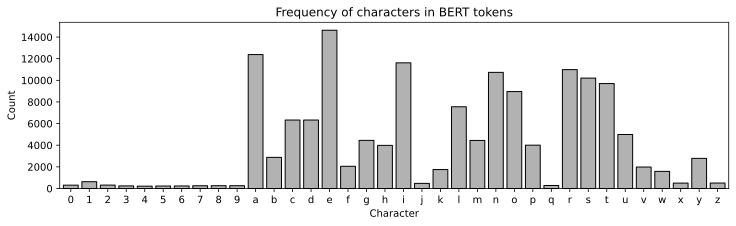

In [13]:
plt.figure(figsize=(12,3))
plt.bar(range(len(charCount)),charCount,color=[.7,.7,.7],edgecolor='k')

plt.gca().set(xticks=range(len(charCount)),xticklabels=list(digitsLetters),
              xlim=[-.6,len(charCount)-.4],xlabel='Character',ylabel='Count',
              title='Frequency of characters in BERT tokens')

plt.show()

In [14]:
charOrder = np.argsort(charCount)[::-1]

for i in charOrder:
  print(f'"{digitsLetters[i]}" appears in {charCount[i]:6,} tokens.')

"e" appears in 14,633 tokens.
"a" appears in 12,381 tokens.
"i" appears in 11,614 tokens.
"r" appears in 10,991 tokens.
"n" appears in 10,735 tokens.
"s" appears in 10,206 tokens.
"t" appears in  9,702 tokens.
"o" appears in  8,961 tokens.
"l" appears in  7,553 tokens.
"d" appears in  6,328 tokens.
"c" appears in  6,326 tokens.
"u" appears in  4,989 tokens.
"g" appears in  4,447 tokens.
"m" appears in  4,445 tokens.
"p" appears in  4,005 tokens.
"h" appears in  3,983 tokens.
"b" appears in  2,874 tokens.
"y" appears in  2,782 tokens.
"f" appears in  2,051 tokens.
"v" appears in  1,982 tokens.
"k" appears in  1,750 tokens.
"w" appears in  1,583 tokens.
"1" appears in    627 tokens.
"z" appears in    501 tokens.
"x" appears in    498 tokens.
"j" appears in    474 tokens.
"2" appears in    310 tokens.
"0" appears in    306 tokens.
"q" appears in    275 tokens.
"8" appears in    259 tokens.
"9" appears in    254 tokens.
"7" appears in    251 tokens.
"3" appears in    236 tokens.
"6" appear